# Evaluación del árbol de decisión

Este notebook selecciona una configuración por **F1 macro medio anual** mediante
`RandomizedSearchCV` y analiza sus predicciones de validación con tablas y matrices
de confusión. Accuracy y balanced accuracy se muestran como métricas complementarias.

Toda la validación cruzada utiliza exclusivamente `train`, con partidos anteriores
al **1 de enero de 2024**. El test contiene todos los partidos desde esa fecha y
**no se utiliza para entrenar, seleccionar parámetros, predecir ni calcular métricas**.
Su evaluación queda pendiente de autorización explícita.

## 1. Carga del dataset y construcción de atributos

La siguiente celda carga los partidos mediante `load_dataset` y muestra las primeras
filas. Los atributos históricos se calculan con partidos de fecha anterior al partido
representado. Aquí todavía no se entrena el clasificador.


In [1]:
import pandas as pd
from load import load_dataset

dataset = load_dataset("futbol_uruguayo.csv")

print(dataset.head())


                   home                              away       date  gh  ga  \
0           Bella Vista                 Defensor Sporting 1932-03-05   1   2   
1            CA Penarol                       River Plate 1932-03-05   1   1   
2       Central Espanol        Rampla Juniors Futbol Club 1932-03-05   1   0   
3  Montevideo Wanderers                       Racing Club 1932-03-05   3   0   
4              Nacional  Institucion Atletica Sud America 1932-03-05   2   0   

  result  record_difference  last_matches_difference  goal_difference_value  \
0      V                0.0                      0.0                    0.0   
1      E                0.0                      0.0                    0.0   
2      L                0.0                      0.0                    0.0   
3      L                0.0                      0.0                    0.0   
4      L                0.0                      0.0                    0.0   

   attack_difference  defense_difference  dr

## 2. Separación temporal entre desarrollo y test

La celda define un único corte temporal:

- **`train`:** todos los partidos hasta diciembre de 2023 inclusive. De aquí salen
  tanto los ejemplos de entrenamiento como los de validación de cada fold.
- **`test`:** todos los partidos desde enero de 2024, sin límite superior de año.
  Solo se separan y se cuenta su cantidad; no se evalúan.

Las comprobaciones verifican que ambas partes respeten el corte.


In [2]:
# El corte separa desarrollo y test por fecha, sin mezclar partidos.
test_start = pd.Timestamp("2024-01-01")

train = dataset[dataset["date"] < test_start].copy()
test = dataset[dataset["date"] >= test_start].copy()

assert not train.empty, "El conjunto de entrenamiento esta vacio"
assert (train["date"] < test_start).all()
assert (test["date"] >= test_start).all()

print("Partidos disponibles para entrenamiento y validacion cruzada:", len(train))
print("Partidos de test reservados desde 2024 (sin evaluar):", len(test))


Partidos disponibles para entrenamiento y validacion cruzada: 14734
Partidos de test reservados desde 2024 (sin evaluar): 472


## 3. Creación del pipeline y configuración de referencia

La celda crea el ID3 y el pipeline de discretización con la configuración inicial
existente. Esta configuración se incluye como referencia en la búsqueda; no se
supone que sea automáticamente el ganador de una ejecución anterior.

La creación del pipeline no entrena el modelo. Los atributos, hiperparámetros y sus
rangos se mantienen como estaban en esta versión del notebook.


In [3]:
import sys
import os

from pipeline import create_model_pipeline, pipeline_input_attributes


# Agrega la carpeta padre (Tarea1) al path de búsqueda de Python
sys.path.append(os.path.abspath(".."))


# Creamos el estimador; esta celda no lo entrena.
from decisionTree.classifier import Classifier as DecisionTreeClassifier

treeID3 = DecisionTreeClassifier(min_info_gain=0.0065)

# Configuracion inicial de referencia; la busqueda probara los rangos de abajo.
model = create_model_pipeline(
    treeID3,
    record_margin=0.07,
    last_matches_margin=0.0,
    goal_difference_margin=0.8,
    attack_margin=0.25,
    defense_margin=0.02,
    draw_low_threshold=0.16,
    draw_high_threshold=0.38
)

## 4. Entradas y clases para la validación cruzada

La celda separa `X_train` (atributos) e `y_train` (resultado del partido) a partir de
`train`. Son los únicos datos que recibe `search.fit`.

No se preparan `X_test` ni `y_test`: el test permanece reservado para otra etapa.


In [4]:
X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

print("Filas disponibles para los folds de entrenamiento/validacion:", len(X_train))
print("El test permanece reservado y no se prepara para predecir en este notebook.")


Filas disponibles para los folds de entrenamiento/validacion: 14734
El test permanece reservado y no se prepara para predecir en este notebook.


## 5. Construcción de los folds temporales

Se conserva el esquema existente: validar cada año de **1950 a 2022 inclusive**,
entrenando con los **cinco años anteriores**. Por ejemplo, para validar 2022 se
entrena con 2017–2021. Todos los índices se calculan sobre `train`, nunca sobre `test`.

Aunque `train` contiene datos hasta diciembre de 2023, la lista actual de años de
validación termina en 2022. Mantenerla evita cambiar el período del experimento
mientras se ordena su presentación. Cambiar esos años será una decisión separada.

Los atributos usan antecedentes disponibles antes de cada partido; el esquema
representa predicción partido a partido, con el árbol fijo durante cada año validado.
La celda imprime los tamaños y comprueba que el entrenamiento preceda a la validación.


In [5]:
import numpy as np

#cada temporada se valida usando solamente las temporadas anteriores
# Validamos usando todo el historial moderno (desde 1950)
validation_years = list(range(2013, 2023))
train_years = train["date"].dt.year.to_numpy()
window_years = 5 # Cada fold entrena con los cinco anos anteriores.
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    # Ambos indices se refieren a X_train/y_train, nunca al conjunto de test.
    assert len(fit_indices) > 0 and len(validation_indices) > 0, "Fold vacio"
    assert train.iloc[fit_indices]["date"].max() < train.iloc[validation_indices]["date"].min()
    assert (train.iloc[validation_indices]["date"] < test_start).all()

    temporal_splits.append((
        fit_indices,
        validation_indices
    ))

    print(
        f"Validacion {validation_year}:",
        f"entrenamiento={len(fit_indices)},",
        f"validacion={len(validation_indices)}"
    )

Validacion 2013: entrenamiento=1231, validacion=241
Validacion 2014: entrenamiento=1221, validacion=243
Validacion 2015: entrenamiento=1209, validacion=241
Validacion 2016: entrenamiento=1207, validacion=240
Validacion 2017: entrenamiento=1206, validacion=302
Validacion 2018: entrenamiento=1267, validacion=261
Validacion 2019: entrenamiento=1287, validacion=299
Validacion 2020: entrenamiento=1343, validacion=175
Validacion 2021: entrenamiento=1277, validacion=367
Validacion 2022: entrenamiento=1404, validacion=298


## 6. Búsqueda aleatoria y selección del ganador

La celda conserva los rangos de búsqueda, **500 candidatos**, **semilla 42** y el
muestreo de combinaciones sin reemplazo. Incluye la configuración inicial como referencia.
`RandomizedSearchCV` compara todos los candidatos con los mismos folds temporales.

**Criterio de selección:** `selection_metric = "f1_macro"`. Para cada candidato se
calcula F1 macro en cada año y se promedian esos valores: cada año pesa igual.
Accuracy y balanced accuracy se calculan también, pero no eligen al ganador.
Por eso el accuracy mostrado es el del ganador por F1, no necesariamente el máximo
accuracy encontrado entre todos los candidatos.

`refit` ajusta automáticamente el ganador sobre todo `X_train` (hasta diciembre de
2023). Ese ajuste no modifica las métricas de los folds ni utiliza el test. La forma
del entrenamiento para una futura evaluación de test se revisará al autorizar esa etapa.

Los resultados sirven para seleccionar configuraciones sobre estos años de validación;
no constituyen una evaluación final independiente. Ejecutar esta celda inicia la búsqueda.


In [6]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

#buscamos los limites de la tendencia al empate y la ganancia minima
# Busqueda local alrededor de los ganadores registrados en el CSV.
param_grid = {
    "preprocessing__differences__discretizer__rest_days_margin": [
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        6.0,
        7.0
    ],
    "model__min_info_gain": [
        0.0045,
        0.005,
        0.0055,
        0.00575,
        0.006,
        0.00625,
        0.0065,
        0.00675,
        0.007,
        0.00725,
        0.0075,
        0.008,
        0.0085
    ],
    "preprocessing__differences__discretizer__attack_margin": [
        0.2,
        0.21,
        0.22,
        0.23,
        0.24,
        0.245,
        0.25,
        0.255,
        0.26,
        0.27,
        0.28,
        0.3
    ],
    "preprocessing__differences__discretizer__defense_margin": [
        0.0,
        0.005,
        0.01,
        0.0125,
        0.015,
        0.0175,
        0.02,
        0.0225,
        0.025,
        0.0275,
        0.03,
        0.035,
        0.04
    ],
    "preprocessing__differences__discretizer__elo_margin": [
        25.0,
        50.0,
        75.0,
        100.0,
        150.0
    ],
    "preprocessing__differences__discretizer__goal_difference_margin": [
        0.7,
        0.725,
        0.75,
        0.775,
        0.7875,
        0.8,
        0.8125,
        0.825,
        0.85,
        0.875,
        0.9
    ],
    "preprocessing__differences__discretizer__last_matches_margin": [
        0.0,
        0.001,
        0.005,
        0.01,
        0.02,
        0.03,
        0.04,
        0.05,
        0.06,
        0.07
    ],
    "preprocessing__differences__discretizer__record_margin": [
        0.05,
        0.055,
        0.06,
        0.0625,
        0.065,
        0.0675,
        0.07,
        0.0725,
        0.075,
        0.0775,
        0.08,
        0.085
    ],
    "preprocessing__draw_rate__discretizer__high_threshold": [
        0.35,
        0.36,
        0.37,
        0.375,
        0.3775,
        0.38,
        0.3825,
        0.385,
        0.39,
        0.395,
        0.4,
        0.41
    ],
    "preprocessing__draw_rate__discretizer__low_threshold": [
        0.14,
        0.145,
        0.15,
        0.1525,
        0.155,
        0.1575,
        0.16,
        0.1625,
        0.165,
        0.1675,
        0.17,
        0.175,
        0.18
    ]
}

selection_metric = "f1_macro"

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

# search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring=scoring,
#     refit=selection_metric,
#     cv=temporal_splits,
#     n_jobs=-1,
#     verbose=1,
# )

# Muestreamos sin enumerar la grilla completa (supera el limite de Windows).
# Cada diccionario representa una combinacion; evitamos repetir candidatos.
import random
from math import prod

n_iter = 500
random_state = 42
rng = random.Random(random_state)
parameter_names_search = sorted(param_grid)
candidate_count = min(n_iter, prod(len(values) for values in param_grid.values()))
# Incluimos la configuracion inicial de model como referencia y 499 candidatos aleatorios.
baseline_parameters = model.get_params()
baseline_values = tuple(baseline_parameters[name] for name in parameter_names_search)
sampled_parameters = [{name: [value] for name, value in zip(parameter_names_search, baseline_values)}]
seen_parameters = {baseline_values}
while len(sampled_parameters) < candidate_count:
    values = tuple(rng.choice(param_grid[name]) for name in parameter_names_search)
    if values not in seen_parameters:
        seen_parameters.add(values)
        sampled_parameters.append({
            name: [value] for name, value in zip(parameter_names_search, values)
        })

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=sampled_parameters,
    n_iter=candidate_count,
    scoring=scoring,
    cv=temporal_splits, # 73 divisiones temporales
    n_jobs=-1,
    refit=selection_metric,
    random_state=random_state,
    verbose=1,
)

search.fit(X_train, y_train)

print("Hiperparametros seleccionados por F1 macro medio anual:")
print(search.best_params_)
print(f"F1 macro medio anual del ganador: {search.best_score_:.3%}")
best_acc = search.cv_results_["mean_test_accuracy"][search.best_index_]
print(f"Accuracy media anual del mismo ganador: {best_acc:.3%}")
best_balanced_acc = search.cv_results_["mean_test_balanced_accuracy"][search.best_index_]
print(f"Balanced accuracy media anual del mismo ganador: {best_balanced_acc:.3%}")


Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Hiperparametros seleccionados por F1 macro medio anual:
{'preprocessing__draw_rate__discretizer__low_threshold': 0.15, 'preprocessing__draw_rate__discretizer__high_threshold': 0.35, 'preprocessing__differences__discretizer__rest_days_margin': 4.0, 'preprocessing__differences__discretizer__record_margin': 0.06, 'preprocessing__differences__discretizer__last_matches_margin': 0.005, 'preprocessing__differences__discretizer__goal_difference_margin': 0.775, 'preprocessing__differences__discretizer__elo_margin': 50.0, 'preprocessing__differences__discretizer__defense_margin': 0.0275, 'preprocessing__differences__discretizer__attack_margin': 0.25, 'model__min_info_gain': 0.007}
F1 macro medio anual del ganador: 40.426%
Accuracy media anual del mismo ganador: 42.791%
Balanced accuracy media anual del mismo ganador: 40.739%


## 7. Tabla de candidatos ordenada por el mismo criterio

La celda construye `results` y la ordena por **`rank_test_f1_macro`**, de forma
consistente con la selección de la búsqueda. La tabla visible muestra los primeros
diez candidatos con las tres métricas, sus desviaciones entre años y sus parámetros.

- `mean_test_*`: promedio de la métrica entre los años de validación.
- `std_test_*`: desviación de la métrica entre esos años; no es un intervalo de confianza.
- `rank_test_*`: posición del candidato según esa métrica (1 es la mejor).

En estos nombres, **`test` es la terminología interna de scikit-learn para la parte
validada de cada fold**: no significa que se haya usado nuestro conjunto `test` desde
2024. `results` conserva además las columnas por año, como `f1_macro_2022`.


In [7]:
from IPython.display import display

results = pd.DataFrame(search.cv_results_)

parameter_columns = [column for column in results.columns if column.startswith("param_")]
# Primero mostramos el criterio de seleccion; las otras metricas lo complementan.
metric_names = [search.refit] + [metric for metric in scoring if metric != search.refit]
summary_columns = [
    f"{stat}_test_{metric}"
    for metric in metric_names
    for stat in ("mean", "std", "rank")
]
split_columns = [
    f"split{i}_test_{metric}"
    for metric in metric_names
    for i in range(len(validation_years))
]

results = results[parameter_columns + summary_columns + split_columns].sort_values(
    f"rank_test_{search.refit}", kind="stable"
)
rename_dict = {
    f"split{i}_test_{metric}": f"{metric}_{year}"
    for metric in metric_names
    for i, year in enumerate(validation_years)
}
results = results.rename(columns=rename_dict)

print("Primeros 10 candidatos, ordenados por F1 macro medio anual (mayor es mejor):")
display(results[summary_columns + parameter_columns].head(10))
# results conserva tambien las metricas de cada ano para inspeccionarlas.


Primeros 10 candidatos, ordenados por F1 macro medio anual (mayor es mejor):


,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy,param_preprocessing__draw_rate__discretizer__low_threshold,param_preprocessing__draw_rate__discretizer__high_threshold,param_preprocessing__differences__discretizer__rest_days_margin,param_preprocessing__differences__discretizer__record_margin,param_preprocessing__differences__discretizer__last_matches_margin,param_preprocessing__differences__discretizer__goal_difference_margin,param_preprocessing__differences__discretizer__elo_margin,param_preprocessing__differences__discretizer__defense_margin,param_preprocessing__differences__discretizer__attack_margin,param_model__min_info_gain
47,0.404259,0.024506,1,0.427907,0.026111,18,0.407387,0.023603,1,0.1500,0.3500,4.0,0.0600,0.005,0.775,50.0,0.0275,0.250,0.00700
7,0.402871,0.023774,2,0.427873,0.027740,19,0.406738,0.023517,4,0.1450,0.3775,2.0,0.0800,0.000,0.725,50.0,0.0275,0.245,0.00725
34,0.401455,0.021300,3,0.429288,0.026000,13,0.406226,0.022451,6,0.1525,0.4000,1.0,0.0775,0.001,0.750,25.0,0.0250,0.200,0.00550
472,0.401027,0.028519,4,0.430133,0.027556,8,0.406978,0.028231,2,0.1525,0.3500,7.0,0.0625,0.010,0.750,25.0,0.0275,0.260,0.00850
385,0.400535,0.031910,5,0.427770,0.032480,20,0.405300,0.031455,8,0.1450,0.3600,6.0,0.0550,0.040,0.775,25.0,0.0225,0.220,0.00800
444,0.400383,0.029691,6,0.430516,0.033867,6,0.405890,0.031632,7,0.1525,0.3775,1.0,0.0725,0.030,0.900,25.0,0.0300,0.220,0.00625
457,0.400339,0.029386,7,0.431903,0.033897,2,0.406557,0.029486,5,0.1525,0.3950,4.0,0.0750,0.030,0.725,25.0,0.0400,0.220,0.00450
49,0.399040,0.036869,8,0.426347,0.040062,27,0.403881,0.037208,16,0.1525,0.3750,3.0,0.0675,0.050,0.775,50.0,0.0225,0.200,0.00650
170,0.398777,0.031789,9,0.426284,0.034870,28,0.402555,0.031730,24,0.1450,0.4000,1.0,0.0775,0.005,0.750,25.0,0.0050,0.270,0.00725
181,0.398633,0.025876,10,0.423747,0.027724,45,0.402633,0.024926,23,0.1500,0.3750,3.0,0.0600,0.001,0.775,50.0,0.0350,0.245,0.00625


## 8. Matrices de confusión y reporte agrupado de validación

La celda clona la configuración ganadora y vuelve a entrenarla en cada fold. Cada
partido se predice con un árbol que no se entrenó con ese año. Se juntan esas
predicciones para construir las mismas dos matrices gráficas y el reporte por clase.

- **Filas:** clase real. **Columnas:** clase predicha.
- **Primera matriz:** cantidades de partidos.
- **Segunda matriz:** proporciones dentro de cada clase real; su diagonal es el recall.

La tabla adicional distingue dos resúmenes del mismo ganador:

- **Media anual:** primero se calcula la métrica por año y luego se promedia.
- **Validación agrupada:** primero se juntan todos los partidos y luego se calcula la métrica.

Pueden dar números diferentes sin que exista un error. El accuracy agrupado pondera
por cantidad de partidos, mientras que la media anual da igual peso a cada año.
El F1 agrupado se recalcula sobre las predicciones conjuntas; no es el promedio anual.

Las matrices y el reporte corresponden al ganador por F1 macro, no al primer candidato
según accuracy. Son diagnósticos sobre la validación usada para elegirlo; **no usan test**.


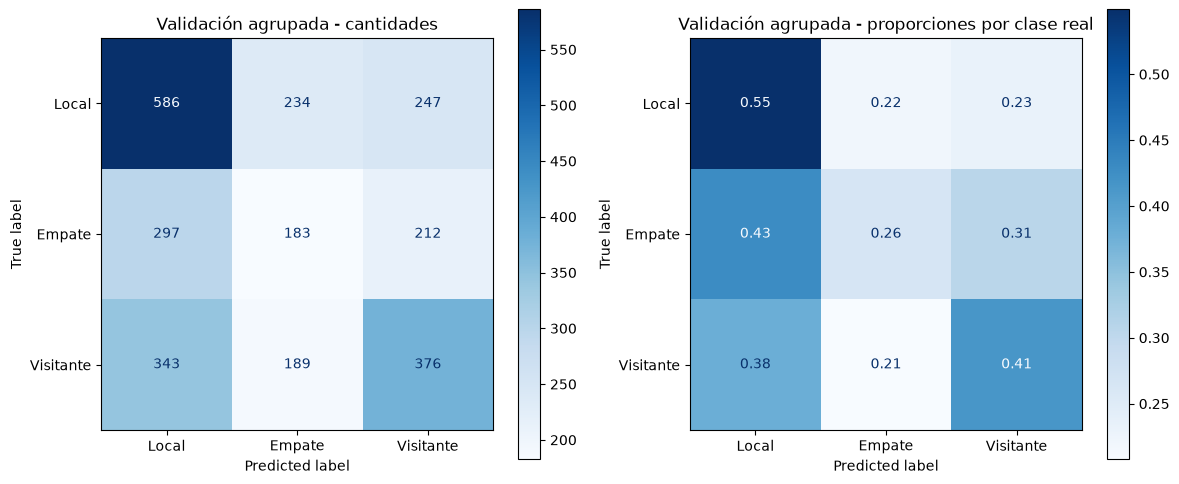

Metricas del ganador seleccionado por F1 macro medio anual:
                   Media anual de validacion cruzada  Validacion agrupada (todos los partidos)
F1 macro                                     40.426%                                   40.818%
Accuracy                                     42.791%                                   42.932%
Balanced accuracy                            40.739%                                   40.925%

Reporte por clase: validacion agrupada; no es una evaluacion de test.
              precision    recall  f1-score   support

       Local       0.48      0.55      0.51      1067
      Empate       0.30      0.26      0.28       692
   Visitante       0.45      0.41      0.43       908

    accuracy                           0.43      2667
   macro avg       0.41      0.41      0.41      2667
weighted avg       0.42      0.43      0.42      2667



In [8]:
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt
import numpy as np


real_results = []
predicted_results = []

#volvemos a entrenar el mejor modelo para cada division temporal
for fit_indices, validation_indices in temporal_splits:

    fold_model = clone(
        search.best_estimator_
    )

    fold_model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    fold_predictions = fold_model.predict(
        X_train.iloc[validation_indices]
    )

    real_results.extend(
        y_train.iloc[validation_indices]
    )

    predicted_results.extend(
        fold_predictions
    )


real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)

labels = ["L", "E", "V"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#cantidad de partidos
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)

axes[0].set_title(
    "Validación agrupada - cantidades"
)

#porcentaje correcto dentro de cada clase real
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)

axes[1].set_title(
    "Validación agrupada - proporciones por clase real"
)

plt.tight_layout()
plt.show()


# Dos resumenes diferentes del mismo ganador y de los mismos folds.
# La media anual da igual peso a cada ano; el agrupado junta todos los partidos.
metrics_summary = pd.DataFrame(
    {
        "Media anual de validacion cruzada": {
            "F1 macro": search.cv_results_["mean_test_f1_macro"][search.best_index_],
            "Accuracy": search.cv_results_["mean_test_accuracy"][search.best_index_],
            "Balanced accuracy": search.cv_results_["mean_test_balanced_accuracy"][search.best_index_],
        },
        "Validacion agrupada (todos los partidos)": {
            "F1 macro": f1_score(real_results, predicted_results, average="macro", zero_division=0),
            "Accuracy": accuracy_score(real_results, predicted_results),
            "Balanced accuracy": balanced_accuracy_score(real_results, predicted_results),
        },
    }
)
print("Metricas del ganador seleccionado por F1 macro medio anual:")
print(metrics_summary.to_string(float_format=lambda value: f"{value:.3%}"))
print("\nReporte por clase: validacion agrupada; no es una evaluacion de test.")
print(
    classification_report(
        real_results,
        predicted_results,
        labels=labels,
        target_names=[
            "Local",
            "Empate",
            "Visitante",
        ],
        zero_division=0,
    )
)

## 9. Registro del experimento

La celda conserva el registro en `experimentos_tree.csv`, agregando una fila por
 ejecución sin borrar el historial. Guarda parámetros, años, ventana y resultados.

Los campos `cv_accuracy`, `cv_f1_macro` y `cv_balanced_accuracy` son **medias anuales**
del ganador por F1 macro. `reporte_validacion` contiene el **reporte agrupado** de los
mismos folds. `n_train` cuenta las filas disponibles en `train`, no el tamaño de cada fold.
`n_test_reservado` solo registra cuántos partidos se reservaron; no contiene métricas de test.

Ejecutar nuevamente solo esta celda agrega otra fila con los resultados que estén en
memoria. Para registrar una corrida nueva, ejecutar antes las celdas de búsqueda y reporte.


In [9]:
# Registro persistente: ejecutar al terminar cada experimento.
import csv
import json
from datetime import datetime, timezone
from pathlib import Path
import load

# Guardamos junto al dataset, independientemente del directorio de ejecucion.
csv_path = Path(load.__file__).resolve().parent / "experimentos_tree.csv"
best_index = search.best_index_
best_parameters = search.best_estimator_.get_params()
parameter_names = [
    "model__min_info_gain",
    "preprocessing__differences__discretizer__record_margin",
    "preprocessing__differences__discretizer__last_matches_margin",
    "preprocessing__differences__discretizer__goal_difference_margin",
    "preprocessing__differences__discretizer__attack_margin",
    "preprocessing__differences__discretizer__defense_margin",
    "preprocessing__differences__discretizer__elo_margin",
    "preprocessing__draw_rate__discretizer__low_threshold",
    "preprocessing__draw_rate__discretizer__high_threshold",
]
experiment = {
    "fecha_utc": datetime.now(timezone.utc).isoformat(),
    "origen": "ejecucion",
    "validation_years": json.dumps(validation_years),
    "window_years": window_years,
    "n_train": len(X_train),
    "n_test_reservado": len(test),
    "param_grid": json.dumps(param_grid, sort_keys=True),
    "mejores_parametros": json.dumps({
        name: best_parameters[name] for name in parameter_names
    }, sort_keys=True),
    "refit": search.refit,
    "cv_accuracy": search.cv_results_["mean_test_accuracy"][best_index],
    "cv_f1_macro": search.cv_results_["mean_test_f1_macro"][best_index],
    "cv_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][best_index],
    "reporte_validacion": classification_report(
        real_results, predicted_results, labels=labels,
        target_names=["Local", "Empate", "Visitante"], zero_division=0,
    ),
    "notas": f"Muestreo directo sin reemplazo; n_iter={candidate_count}; semilla={random_state}; cv_* son medias anuales; reporte_validacion es agrupado; test sin evaluar",
}
# Mantener una sola linea por experimento en el CSV.
experiment["reporte_validacion"] = " | ".join(
    " ".join(line.split())
    for line in experiment["reporte_validacion"].splitlines() if line.strip()
)
has_header = csv_path.exists() and csv_path.stat().st_size > 0
if has_header:
    with csv_path.open(newline="", encoding="utf-8") as file:
        if next(csv.reader(file)) != list(experiment):
            raise ValueError("El CSV tiene columnas incompatibles; no se modifico.")
with csv_path.open("a", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=experiment)
    if not has_header:
        writer.writeheader()
    writer.writerow(experiment)
print(f"Experimento guardado en {csv_path}")


Experimento guardado en D:\Repo Aprendizaje Automatico\AprendizajeAutomatico\Tarea1\dataset\experimentos_tree.csv
